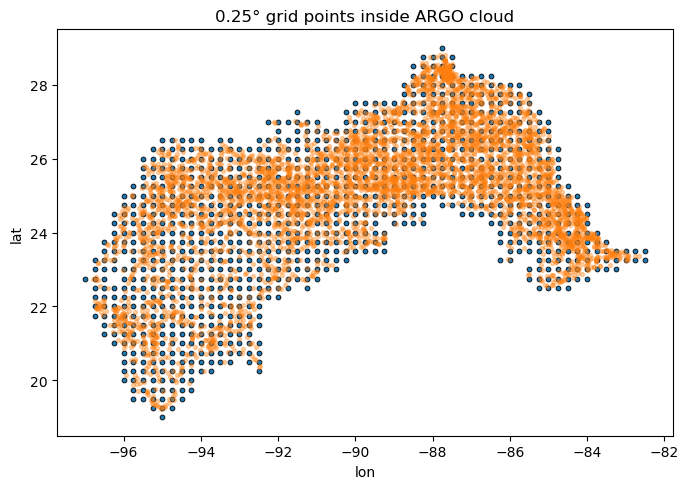

In [ ]:
import numpy as np
import mat73
import matplotlib.pyplot as plt

from shapely.geometry import Point, MultiPoint, Polygon
from shapely.ops import unary_union
from shapely.prepared import prep

# --- load data ---
data = mat73.loadmat("/unity/g2/jmiranda/SubsurfaceFields/Data/ARGO_GoM_20220920.mat")
LAT = np.asarray(data["LAT"]).ravel()
LON = np.asarray(data["LON"]).ravel()

# --- build a 0.125°-resolved boundary of the cloud ---
# Buffer every point by 0.125°, union, and clean topology. (join_style=2 -> miter corners)
buf_r = 0.25
# If memory is tight, chunk the union; otherwise this one-liner is fine:
region = MultiPoint(np.c_[LON, LAT]).buffer(buf_r, resolution=8, join_style=2).buffer(0)

# # fill all interior void
# def outer_shell(geom):
#     if geom.geom_type == "Polygon":
#         return Polygon(geom.exterior)
#     elif geom.geom_type == "MultiPolygon":
#         return unary_union([Polygon(p.exterior) for p in geom.geoms])
#     return geom

# region_filled = outer_shell(region)

region_prep = prep(region)  # speeds up many contains() calls

# --- make a regular 0.25° grid over the bbox of the cloud (with a little padding) ---
step = 0.25
pad  = buf_r
lon_min, lon_max = LON.min() - pad, LON.max() + pad
lat_min, lat_max = LAT.min() - pad, LAT.max() + pad

# snap to exact 0.25° ticks
lon_ticks = np.arange(np.floor(lon_min/step)*step, np.ceil(lon_max/step)*step + 1e-12, step)
lat_ticks = np.arange(np.floor(lat_min/step)*step, np.ceil(lat_max/step)*step + 1e-12, step)
XX, YY = np.meshgrid(lon_ticks, lat_ticks)

# --- pick grid points inside the buffered cloud ---
lon_grid = XX.ravel()
lat_grid = YY.ravel()
inside_mask = np.fromiter(
    (region_prep.contains(Point(x, y)) for x, y in zip(lon_grid, lat_grid)),
    dtype=bool,
    count=lon_grid.size
)

lon_in = lon_grid[inside_mask]
lat_in = lat_grid[inside_mask]




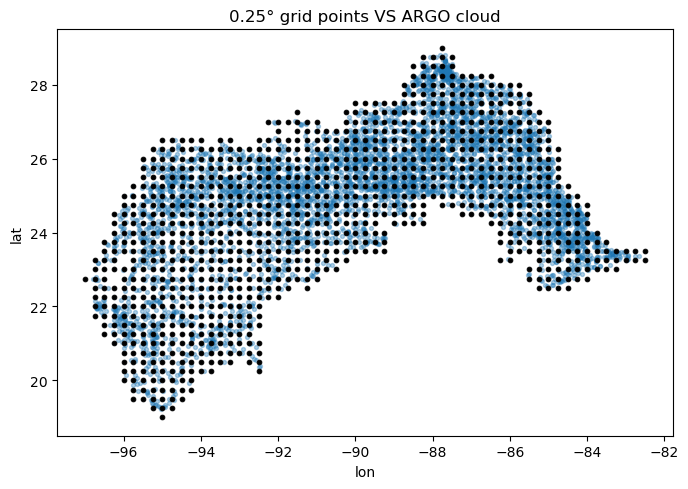

In [24]:

plt.figure(figsize=(7,5))
plt.scatter(LON, LAT, s=8, alpha=0.35)
plt.scatter(lon_in, lat_in, s=12, color='k', linewidths=0.6)
plt.title("0.25° grid points VS ARGO cloud")
plt.xlabel("lon"); plt.ylabel("lat"); plt.tight_layout(); plt.show()

In [15]:
#export lon_grid, lat_grid and inside_mask in a pickle file
import pickle

data = {
    "lon_grid": lon_grid,
    "lat_grid": lat_grid,
    "inside_mask": inside_mask
}

with open("nespreso_grid_and_mask.pkl", "wb") as f:
    pickle.dump(data, f)




In [16]:
#test loading the pickle file
with open("nespreso_grid_and_mask.pkl", "rb") as f:
    data = pickle.load(f)

print(data)

{'lon_grid': array([-97.25, -97.  , -96.75, ..., -82.75, -82.5 , -82.25], shape=(2623,)), 'lat_grid': array([18.75, 18.75, 18.75, ..., 29.25, 29.25, 29.25], shape=(2623,)), 'inside_mask': array([False, False, False, ..., False, False, False], shape=(2623,))}
